LA LOSS FUNCTION DEL VAE: RICOSTRUZIONE E DIVERGENZA KL

La Loss Function del VAE è il punto in cui si vede la differenza tra Autoencoder (AE) e Variatinal Autoencoder (VAE)

VAE Loss = Reconstruction Loss + KL Divergence

La Reconstruction Loss dice: "ricostruisci bene il dato originale"
La KL Divergence dice: "organizza bene il laten space" organizza sencondo un ordine logico.

La rete deve essere sia precisa che ordinata, grazie alla funzione di perdita.

Senza la prima il decoder non imparerebbe a ricostruire. Senza la seconda, avresti un Autoencoder classico con un po' di rumore.

Flusso del codice VAE:
x -> Encoder -> mu, logvar -> z -> Decoder -> x circa

Il primo componente è quindi la Reconstruction Loss, confronto il dato orginale (es. l'immagine originale) con il dato ricostruito.
Se sono simili la loss sarà bassa (es. 0.1) se sono molto diverse, allora la loss sarà alta (es. 0.9). Piu i due dati sono diversi, maggiore sarà la loss
Per immagini normalizzate tra 0 e 1 viene spesso utilizzata la Binary Cross Entropy. Ma si può usare anche MSE, la scelta dipende dal modello probabilistico dei dati e dal tipo di output.

Fin qui AE e VAE sono simili, anche AE ha una Reconstruction Loss
La parte specifica della VAE è: KL Divergence.
La KL Divergence misura la distanza tra la distribuzione prodotta dall'Encoder e la distribuzione standard desiderata.

Il Quadro Teorico: ELBO
Massimizzare la verosomiglianza dei dati
Calcolare la probabilità esatta dei dati è intrattabile (richederebbe di analizzare ogni singola variabile infinita nello spazio latente), nei VAE ottimizziamo un limite inferiore chiamato Evidnece Lower Bound o ELBO.
Invece di cercare di scalare una montagna troppo alta costruiamo una piattforma solita,  un limite inferiore, e cerchiamo di spingerla il piu in alto possibile
Massimizzare l'ELBO è il modo matematico per dire alla rete: "avvicinati il più possibile alla versa distribuzione dei dati, anche se non puoi vederla direttamente" equivale a minimizzare la discrepanza tra la nostra approssimazione variazionale e la vera distribuzione dei dati.
Massimizzare l'ELBO è dire alla rete: avvicinati il può possibile alla versa distribuzione dei dati, anche se non puoi 

Vediamo come si scompone questo calcolo.

Anatomia della Perdita
La scomposizione matematica dell'obiettivo.
La funzione obiettivo si compone di due termini con scopo opposti: precisione e regolarità
Il primo termine, la precisione, spinge il decoder a riprodurre l'input fedelmente. Guarda al passato.
Il secondo termine, la regolarità, spinge l'encoder a organizzare lo spazio latente secondo una distribuzione nota, in modo che sia facile campionare nuovi dati. Guarda la futuro
E' un conflitto di interesse, la precisione vorrebbea assegnare a ogni dato un punto isolato e perfetto, ma la regolarità vuole che tutto sia compatto e sovrapposto.
L'obbiettivo finale è minimizzare il negativo dell'ELBO, trasformando il problema in una classica minimizzazione del costo.

Questo processo crea quello che chiamo l'Equilibrio Variazionale.
Stiamo addestrando simultaneamente encoder e decoder in una danza duale, per trovare un compromesso tra compressione e fedeltà.
Il Lower Bound è il limite inferiore perchè garantisce che la log-verosomiglianza sia sempre superiore o uguale all'ELBO stesso.
Entrambi i termini contribuiscono all'aggiornameto dei pesi, permettendo alla rete di imparare la struttura semantica del manifold.
L'ELBO ci garantisce che fintanto che la nostra funzione di perdita scende, la verosomiglianza dei dati sta salendo, è la nostra assicurazione sulla vita metematica, ci conferma che il modello non sta solo memorizzando a caso, sta imparando la struttura sementica.

Come siamo passasti dalla verosomiglianda all'ELBO (limite inferiore)

Dalla Verosomiglianza all'ELBO
Minimizzare la distanza informativa.
Tutto nasce dalla disuguaglianza di Jensen. 

Il Termine di Ricostruzione
La qualità visiva dell'output
Il Reeconstruction Term misura quanto bene il decoder riesce a rigenerare l immagine originale partendo dal codice latente 'z' campionato.
Questo termine è tecnicamente la log-verosomiglianza attesa dall'input dato il codice estratto dalla distribuzione approssimata dell'encoder.
Se dai un gatto come immagine al VAE non restituisce una sedia, stiamo calcolando quanto è probabile che un immagine originale x sia stata geneerata proprio da quel codice z che l'encoder ha estratto. Senza questo termine encoder non avrebbe alun motivo di guardare l'input, si limiterebbe a produrre rumore casuale che rispetti la statistica ma senza alcun contenuto.

Ma come scegliamo il metro per misurare questa distanza visiva
La scelta dalla funzione di costo dipende dalla nostra interpretazione dei dati.
Se trattiamo i pixel come interrutori acceso/spento, la Binary Cross-Entropy è la scelta perfetta per pulire ogni pixel fuori posto.
Se consideriamo i pixel come valore continui (come distribuzione gaussiana) allora usiamo l'errore quadratico medio (MSE).
In ogni caso l'obbiettivo è identico, Massimizzare la probabilità che l'input originale x sia generato correttamente dal codice z.

Il Ruolo del Decoder.
Il Decoder ha un ruolo poi importante,deve imparare a ignorare il rumore introdotto dal campionamento per focalizzarsi sui tratti strutturali del dato (mapping latente).
Poichè massimizziamo la verosomiglianza media, il modello tende a produrre immagini più morbide e sfuocate rispetto alla precisione delle GAN (sfocatura dei VAE).
Il decoder impara ad essere prudente, preferisce produrre pixel che siano una media accettabile di molte variabili piuttosto che rischiare un dettagli nitido ma sbagliato.
La scelta della loss di ricostruzione riflette le assunzioni statistiche che facciamo sulla natura del segnale di input.

Ma come decidiamo di usare MSE o Cross Entropy in un progetto reale?

La stabilità è tutto
MSE vs Cross-Entropy
Mentre MSE è intuitivo per dati continui, la Cross-Entropy è spesso più stabile per immagini normalizzate tra 0 e 1 come MNIST.
In questo caso la Cross-Entorpy è spesso più aggressiva e veloce a portare il modello alla convergenza.
Poiche non possiamo calcolare l'integrale su tutti i possibili z usiamo l'approssimazione di montecarlo, campioniamo n volte e facciamo la media. Questa scelta influenza non solo la nitidezza dei bordi ma anche la capacità del modello di ricostruire texture complessi senza generare artefatti visivi.

La Divergenza di Kullback-Leibler
Il guardiano della distribuzione
Senza un vincolo, l'encoder potrebbe assegnare ogni dato a una zona isolata dello spazio, distruggendo la continuità necessaria per la generazione.
Risultato? avremmo un ottima ricostruzione ma zero capacità generativa perchè lo spazio sarebbe pieno di buchi inutilizzabili.
Il termine KL Divergence agisce come un regolarizzatore che forza la distribuzione latente ad avvicinarsi a una normale standard.
Obblica l'encoder ad essere oridnato, dice puoi mettere i dati dove vuoi ma la distribuzione totale deve somigliare ad una normale standard.

Questo ordine forzato organizza, fisicamente, lo spazio dei concetti

Organizzazione Latente
Prevenire il collasso deterministico.
La KL penalizza l'encoder se le medie si allontanano dallo zero o se le varianze si allontanano dall'unità (fenomeno che si verifica quando si nascondono i dati in punti microscopici).
Questo termine assicura che lo spazio latente sia denso, senza zone vuote o 'buchi' informativi. Se campionato un punto a metà strata tra il concetto di scarpa ed il concetto di stivale, grazie a KL troverete un'immagine che è un mix tra una scarpa ed uno stivale.
Per due distribuzioni gaussiae, la divergenza KL ha una forma chiusa che rende il calcolo estremamente effciente.
Questo vincolo permette di campionare nuove immagini semplicemente estraendo vettori da una distribuzione normale standard.

Compattare lo Spazio
Il prior p (z) agisce come una forza centripeta che tiene tutti i codici vicini all'origine (centro del grafico).
La KL forza le distribuzioni di diverse classi a sovrapporsi leggermente, permettendo interpolazioni fluide.
Un peso eccessivo alla KL può portare al posterior collapse, dove il modello ignora l'input e genera solo la media del dataset.

Inizio addestramento su cpu...
Epoca [1/10] - Perdita Media: 164.07
Epoca [2/10] - Perdita Media: 121.31
Epoca [3/10] - Perdita Media: 114.48
Epoca [4/10] - Perdita Media: 111.44
Epoca [5/10] - Perdita Media: 109.70
Epoca [6/10] - Perdita Media: 108.53
Epoca [7/10] - Perdita Media: 107.69
Epoca [8/10] - Perdita Media: 107.05
Epoca [9/10] - Perdita Media: 106.51
Epoca [10/10] - Perdita Media: 106.16


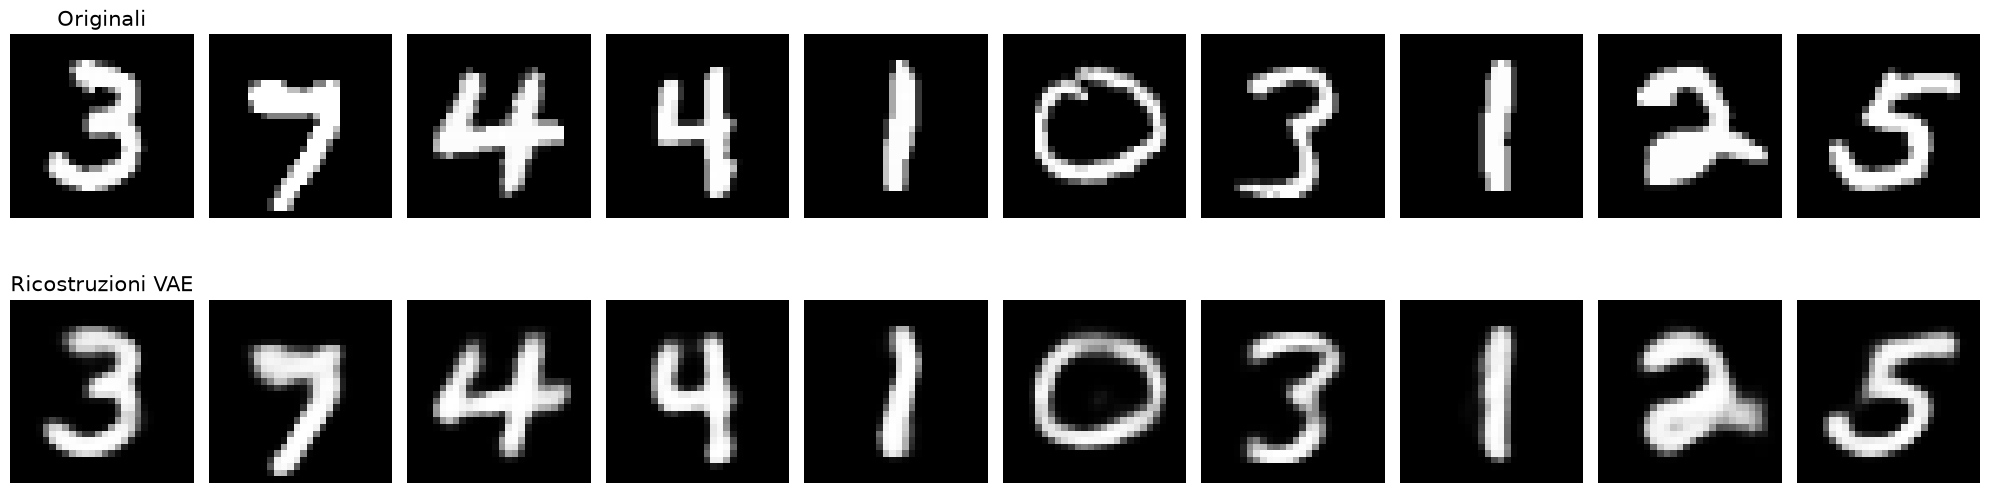

: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- CONFIGURAZIONE E PARAMETRI DI ADDESTRAMENTO ---

# Selezione automatica del dispositivo: usa la GPU (cuda) se disponibile, altrimenti la CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Numero di immagini elaborate contemporaneamente durante l'addestramento.
BATCH_SIZE = 128

# Numero di variabili che compongono la "chiave" di compressione (spazio latente).
# Rappresenta le caratteristiche astratte dell'immagine.
LATENT_DIM = 20

# Quante volte il modello vedrà l'intero dataset durante l'addestramento.
EPOCHS = 10

# Tasso di apprendimento: controlla quanto velocemente il modello aggiorna i suoi parametri.
LR = 1e-3

# --- PREPARAZIONE DEI DATI ---

# Trasformiamo i dati in tensori (formato numerico per PyTorch).
# Questo normalizza i pixel tra 0 e 1, fondamentale per l'interpretazione probabilistica del VAE.
transform = transforms.ToTensor()

# Scarichiamo e carichiamo il dataset MNIST (immagini di cifre scritte a mano).
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Il DataLoader si occupa di dividere il dataset in batch e di mescolare i dati a ogni epoca.
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

# --- ARCHITETTURA DEL VARIATIONAL AUTOENCODER (VAE) ---

class VAE(nn.Module):
    """
    Classe principale che definisce la struttura del Variational Autoencoder.
    Il VAE non si limita a comprimere i dati, ma impara a modellare la loro distribuzione.
    """
    def __init__(self, input_dim=784, hidden_dim=400, latent_dim=20):
        super().__init__()
        
        # L'Encoder comprime l'immagine di input (784 pixel) in una rappresentazione intermedia.
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU() # Funzione di attivazione per introdurre non-linearità.
        )
        
        # Invece di produrre un singolo punto, l'encoder produce i parametri di una distribuzione:
        # 1. Media (mu): il valore centrale della rappresentazione latente.
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        # 2. Log-varianza (logvar): quanto è "diffusa" o incerta questa rappresentazione.
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # Il Decoder riceve un punto dallo spazio latente e cerca di ricostruire l'immagine originale.
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            # Sigmoid assicura che i pixel dell'uscita siano tra 0 e 1 (interpretazione probabilistica).
            nn.Sigmoid() 
        )

    def reparameterize(self, mu, logvar):
        """
        Il Reparameterization Trick permette di campionare dalla distribuzione in modo derivabile.
        Senza questo trucco, il gradiente non potrebbe passare attraverso il campionamento casuale.
        """
        # Calcoliamo la deviazione standard dalla log-varianza.
        std = torch.exp(0.5 * logvar)
        # Generiamo rumore casuale da una distribuzione normale standard.
        eps = torch.randn_like(std)
        # Il punto nello spazio latente è: media + (rumore * deviazione standard).
        return mu + eps * std

    def forward(self, x):
        """
        Definisce il flusso dei dati: Immagine -> Encoder -> Spazio Latente -> Decoder -> Ricostruzione.
        """
        # Appiattiamo l'immagine 28x28 in un vettore di 784 elementi.
        h = self.encoder(x.view(-1, 784))
        
        # Otteniamo i parametri della distribuzione latente.
        mu, logvar = self.fc_mu(h), self.fc_logvar(h)
        
        # Campioniamo un punto 'z' usando il trucco della riparametrizzazione.
        z = self.reparameterize(mu, logvar)
        
        # Restituiamo l'immagine ricostruita, la media e la log-varianza (necessarie per la loss).
        return self.decoder(z), mu, logvar

# --- FUNZIONE DI PERDITA (VAE LOSS / ELBO) ---

def vae_loss_function(recon_x, x, mu, logvar):
    """
    La loss del VAE (ELBO) bilancia due obiettivi opposti:
    1. Fedeltà della ricostruzione.
    2. Regolarità dello spazio latente.
    """
    
    # 1. Perdita di Ricostruzione (Binary Cross Entropy):
    # Confronta pixel per pixel l'immagine originale con quella generata dal decoder.
    # Sommiamo tutte le discrepanze per l'intero batch.
    recon_loss = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')

    # 2. Divergenza KL (Regolarizzazione):
    # Forza lo spazio latente a seguire una distribuzione normale standard N(0, 1).
    # Evita che il modello memorizzi semplicemente gli input anziché imparare le caratteristiche.
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # La perdita totale è la somma dei due termini.
    return recon_loss + kl_loss

# --- CICLO DI ADDESTRAMENTO ---

# Inizializziamo il modello e lo spostiamo sulla GPU/CPU.
model = VAE(latent_dim=LATENT_DIM).to(device)

# L'ottimizzatore Adam aggiornerà i pesi del modello per minimizzare la loss.
optimizer = optim.Adam(model.parameters(), lr=LR)

print(f"Inizio addestramento su {device}...")

for epoch in range(EPOCHS):
    model.train() # Imposta il modello in modalità addestramento.
    train_loss = 0
    
    for data, _ in train_loader:
        # Spostiamo i dati sul dispositivo corretto.
        data = data.to(device)
        
        # Resettiamo i gradienti accumulati per evitare interferenze tra i batch.
        optimizer.zero_grad()
        
        # Passaggio in avanti (Forward Pass): otteniamo la ricostruzione e i parametri latenti.
        recon_batch, mu, logvar = model(data)
        
        # Calcoliamo quanto errore ha commesso il modello (ELBO loss).
        loss = vae_loss_function(recon_batch, data, mu, logvar)
        
        # Calcoliamo i gradienti (Backpropagation).
        loss.backward()
        
        # Accumuliamo la loss per le statistiche dell'epoca.
        train_loss += loss.item()
        
        # Aggiorniamo i pesi del modello.
        optimizer.step()
        
    # Calcolo e stampa della perdita media per immagine in questa epoca.
    avg_loss = train_loss / len(train_loader.dataset)
    print(f"Epoca [{epoch+1}/{EPOCHS}] - Perdita Media: {avg_loss:.2f}")

# --- VALUTAZIONE E VISUALIZZAZIONE DEI RISULTATI ---

# Passiamo alla modalità valutazione (disabilita calcoli non necessari come il dropout se presente).
model.eval()

# Disabilitiamo il calcolo dei gradienti per risparmiare memoria durante l'interferenza.
with torch.inference_mode():
    # Prendiamo un batch di immagini reali per confrontarle con le ricostruzioni del VAE.
    data, _ = next(iter(train_loader))
    data = data.to(device)
    
    # Chiediamo al modello di ricostruire queste immagini.
    recon, _, _ = model(data)

    # Visualizziamo le prime 10 immagini originali e le loro relative ricostruzioni.
    n = 10 
    plt.figure(figsize=(20, 6))
    for i in range(n):
        # Prima riga: Immagini Originali.
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(data[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0: ax.set_title("Originali", fontsize=15)

        # Seconda riga: Immagini Ricostruite dal VAE.
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(recon[i].cpu().view(28, 28), cmap='gray')
        plt.axis('off')
        if i == 0: ax.set_title("Ricostruzioni VAE", fontsize=15)
        
    plt.tight_layout()
    plt.show()